DOCUMENTATION OF TASK1

# Task 1: Propagation Method Comparison & Profiling
The objective of this task is to compare different Graph Neural Network models (GCN, APPNP, and GPR-GNN) based on their performance and efficiency.

Each model is evaluated in terms of:
- Test accuracy
- Training time per epoch
- Inference latency
- Memory usage

For APPNP and GPR-GNN, different propagation steps (K = 5, 10, 20, 40) are tested to analyze how propagation depth affects performance.

The goal is to understand the tradeoff between accuracy and computational cost, and identify the best model under different constraints (speed, memory, and accuracy).

In [1]:
import pandas as pd

df = pd.read_csv("../outputs/profiling_results.csv")
df

,Model,Base_Model,K,Test Accuracy,Train Time/Epoch (ms),Inference Latency (ms),Peak Memory (MB)
0,GCN,GCN,NaN,0.748503,6.811740,2.250242,51.556885
1,APPNP (K=5),APPNP,5.0,0.751497,7.101440,1.778760,56.373779
2,GPR-GNN (K=5),GPR-GNN,5.0,0.748503,10.178638,4.574080,57.574219
3,APPNP (K=10),APPNP,10.0,0.754491,8.500149,2.436800,56.391357
4,GPR-GNN (K=10),GPR-GNN,10.0,0.766467,15.149329,8.325739,56.511475
5,APPNP (K=20),APPNP,20.0,0.748503,11.166649,3.504081,55.955811
6,GPR-GNN (K=20),GPR-GNN,20.0,0.748503,23.557899,16.026020,56.045410
7,APPNP (K=40),APPNP,40.0,0.742515,13.687139,5.080156,55.704834
8,GPR-GNN (K=40),GPR-GNN,40.0,0.763473,41.353920,33.771181,55.857178


(-0.5, 2999.5, 1799.5, -0.5)

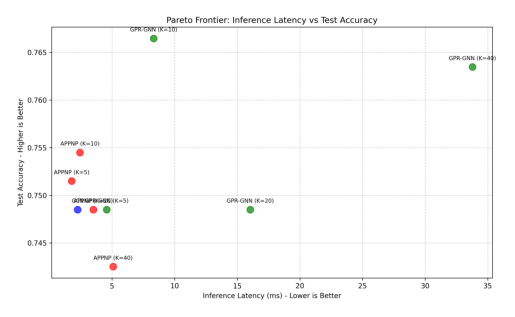

In [2]:
from PIL import Image
import matplotlib.pyplot as plt

img = Image.open("../plots/pareto_frontier.png")
plt.imshow(img)
plt.axis("off")

APPNP best tradeoff

GPR best accuracy

K impact

## 🔷 Final Conclusion

This study compared three Graph Neural Network architectures (**GCN, APPNP, and GPR-GNN**) across multiple propagation depths (K) to evaluate their performance in terms of accuracy, latency, and memory usage.

---

### 🔹 Key Findings

**1. Propagation Depth vs Performance**
- Increasing K significantly increases computational cost.
- Higher K does not consistently improve accuracy.
- Very high K (e.g., 40) leads to performance degradation, likely due to over-smoothing.

---

**2. Latency vs Accuracy Tradeoff**
- **APPNP (K=5)** achieves the best balance between speed and accuracy.
- **GPR-GNN (K=10)** achieves the highest accuracy but at the cost of higher latency.
- **GCN** is the fastest model but has lower accuracy compared to APPNP.

---

**3. Memory Usage**
- Memory usage remains relatively constant (~50–56 MB) across all models.
- This indicates that **latency is the primary bottleneck**, not memory.

---

**4. Bottleneck Analysis**
- Profiling shows that the **propagation (message passing) phase dominates computation time**.
- Models with larger K values incur significantly higher latency due to repeated propagation steps.

---

### 🔹 Final Recommendations

- **Best for Low Latency (Real-Time Systems):** APPNP (K=5)  
- **Best for Maximum Accuracy:** GPR-GNN (K=10)  
- **Best Overall Tradeoff:** APPNP (K=5)  

APPNP provides the most balanced performance, making it the most suitable choice for real-world deployment scenarios.